# Payload Optimization

In [7]:
import pandas as pd

route_data = pd.read_csv(
    "../data/orders_routes_optimized.csv"
)

print("Shape:", route_data.shape)
print("\nColumns:")
print(route_data.columns.tolist())

Shape: (13745, 27)

Columns:
['order_id', 'origin_hub', 'origin_city', 'destination_city', 'destination_state', 'destination_lat', 'destination_lon', 'distance_km', 'package_weight', 'transport_mode', 'vehicle_id', 'vehicle_type', 'capacity_kg', 'max_range_km', 'vehicle_avg_speed_kmph', 'vehicle_capacity_utilization_pct', 'weight_exceeds_capacity', 'delivery_priority', 'calculated_capacity_utilization_pct', 'calculated_weight_exceeds_capacity', 'range_feasible', 'valid_range_feasible', 'capacity_feasible', 'route_feasible', 'priority_score', 'estimated_travel_hours', 'scheduling_score']


# Calculate payload utilization

In [8]:
route_data['payload_utilization_pct'] = (
    route_data['package_weight'] /
    route_data['capacity_kg']
) * 100

print(route_data['payload_utilization_pct'].describe())

count     13745.000000
mean        475.517717
std       14061.682074
min           0.000117
25%           0.075748
50%           3.724880
75%          28.815807
max      876401.538462
Name: payload_utilization_pct, dtype: float64


# Payload utilization for feasible routes

In [9]:
feasible_payload = route_data[
    route_data['route_feasible'] == True
].copy()

print("Feasible routes:", len(feasible_payload))

print(
    feasible_payload['payload_utilization_pct'].describe()
)

Feasible routes: 10813
count    10813.000000
mean        15.663146
std         22.856721
min          0.000117
25%          0.074185
50%          4.088289
75%         23.260870
max        100.000000
Name: payload_utilization_pct, dtype: float64


# Classify payload utilization

In [10]:
feasible_payload['payload_utilization_level'] = pd.cut(
    feasible_payload['payload_utilization_pct'],
    bins=[0, 25, 75, 100],
    labels=[
        'Underutilized',
        'Moderately Utilized',
        'Highly Utilized'
    ],
    include_lowest=True
)

print(
    feasible_payload['payload_utilization_level']
    .value_counts()
    .sort_index()
)

payload_utilization_level
Underutilized          8243
Moderately Utilized    2162
Highly Utilized         408
Name: count, dtype: int64


# Payload Utilization Chart

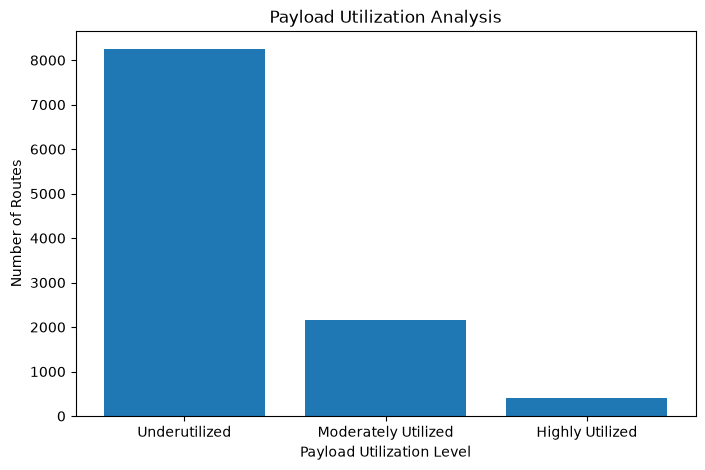

In [11]:
import matplotlib.pyplot as plt

payload_counts = (
    feasible_payload['payload_utilization_level']
    .value_counts()
    .reindex([
        'Underutilized',
        'Moderately Utilized',
        'Highly Utilized'
    ])
)

plt.figure(figsize=(8, 5))

plt.bar(
    payload_counts.index,
    payload_counts.values
)

plt.xlabel("Payload Utilization Level")
plt.ylabel("Number of Routes")
plt.title("Payload Utilization Analysis")

plt.show()

# Analyze drone payload utilization

In [12]:
drone_payload = route_data[
    route_data['vehicle_type'] == 'Drone'
].copy()

print("Total drone routes:", len(drone_payload))

print("\nDrone route feasibility:")
print(drone_payload['route_feasible'].value_counts())

print("\nDrone payload utilization:")
print(
    drone_payload['payload_utilization_pct'].describe()
)

Total drone routes: 759

Drone route feasibility:
route_feasible
True     411
False    348
Name: count, dtype: int64

Drone payload utilization:
count       759.000000
mean       7753.971658
std       59158.931727
min           4.897959
25%          35.942292
50%          72.000000
75%         192.599258
max      876401.538462
Name: payload_utilization_pct, dtype: float64


# analyze only feasible drone payloads

In [13]:
feasible_drones = drone_payload[
    drone_payload['route_feasible'] == True
].copy()

print("Feasible drone routes:", len(feasible_drones))

print("\nFeasible drone payload utilization:")
print(
    feasible_drones['payload_utilization_pct'].describe()
)

Feasible drone routes: 411

Feasible drone payload utilization:
count    411.000000
mean      45.693978
std       24.200830
min        5.932203
25%       27.131410
50%       39.310345
75%       65.950110
max      100.000000
Name: payload_utilization_pct, dtype: float64


# classify feasible drone utilization

In [14]:
feasible_drones['payload_utilization_level'] = pd.cut(
    feasible_drones['payload_utilization_pct'],
    bins=[0, 25, 75, 100],
    labels=[
        'Underutilized',
        'Moderately Utilized',
        'Highly Utilized'
    ],
    include_lowest=True
)

print(
    feasible_drones['payload_utilization_level']
    .value_counts()
    .sort_index()
)

payload_utilization_level
Underutilized           93
Moderately Utilized    261
Highly Utilized         57
Name: count, dtype: int64


Identify underutilized drone routes

In [15]:
underutilized_drones = feasible_drones[
    feasible_drones['payload_utilization_pct'] < 25
].copy()

print("Underutilized drone routes:", len(underutilized_drones))

print(
    underutilized_drones[
        [
            'order_id',
            'origin_city',
            'destination_city',
            'vehicle_id',
            'package_weight',
            'capacity_kg',
            'payload_utilization_pct',
            'distance_km',
            'max_range_km',
            'delivery_priority'
        ]
    ].head(10)
)

Underutilized drone routes: 93
      order_id    origin_city destination_city vehicle_id  package_weight  \
11  ORD-004555       Gurugram         Gurugram   VEH-0008            0.60   
23  ORD-014095         Nagpur           Nagpur   VEH-0100            0.44   
31  ORD-014136        Madurai          Madurai   VEH-0075            0.86   
40  ORD-014231  Visakhapatnam    Visakhapatnam   VEH-0108            0.37   
43  ORD-001938       Gurugram         Gurugram   VEH-0039            0.80   
55  ORD-014139          Delhi            Delhi   VEH-0071            0.72   
58  ORD-002349       Gurugram         Gurugram   VEH-0131            0.53   
63  ORD-008813    Bhubaneswar      Bhubaneswar   VEH-0112            0.88   
66  ORD-011703        Lucknow          Lucknow   VEH-0079            1.28   
95  ORD-014847          Delhi            Delhi   VEH-0087            0.64   

    capacity_kg  payload_utilization_pct  distance_km  max_range_km  \
11          3.9                15.384615         1

# Find consolidation opportunities

In [ ]:
underutilized_drones['unused_capacity_kg'] = (
    underutilized_drones['capacity_kg'] -
    underutilized_drones['package_weight']
)

print("Total unused drone capacity:",
      round(underutilized_drones['unused_capacity_kg'].sum(), 2),
      "kg")

print("\nAverage unused capacity:",
      round(underutilized_drones['unused_capacity_kg'].mean(), 2),
      "kg")

print("\nMaximum unused capacity:",
      round(underutilized_drones['unused_capacity_kg'].max(), 2),
      "kg")                     

Total unused drone capacity: 368.14 kg

Average unused capacity: 3.96 kg

Maximum unused capacity: 5.55 kg


# Find compatible drone deliveries

In [17]:
# Sort potential consolidation candidates
consolidation_candidates = underutilized_drones.sort_values(
    by=[
        'origin_city',
        'destination_city',
        'delivery_priority',
        'package_weight'
    ]
).copy()

print(
    consolidation_candidates[
        [
            'order_id',
            'origin_city',
            'destination_city',
            'vehicle_id',
            'package_weight',
            'capacity_kg',
            'delivery_priority'
        ]
    ].head(20)
)

        order_id  origin_city destination_city vehicle_id  package_weight  \
1784  ORD-012272    Ahmedabad        Ahmedabad   VEH-0023            0.72   
103   ORD-012145    Ahmedabad        Ahmedabad   VEH-0137            1.15   
5732  ORD-001984    Ahmedabad        Ahmedabad   VEH-0086            0.35   
5859  ORD-011952    Ahmedabad        Ahmedabad   VEH-0090            0.66   
2537  ORD-014799    Bengaluru        Bengaluru   VEH-0080            0.75   
2153  ORD-013573    Bengaluru        Bengaluru   VEH-0068            0.96   
1804  ORD-001498  Bhubaneswar      Bhubaneswar   VEH-0027            0.35   
2029  ORD-008049  Bhubaneswar      Bhubaneswar   VEH-0002            0.36   
2028  ORD-007403  Bhubaneswar      Bhubaneswar   VEH-0082            0.86   
2522  ORD-006747  Bhubaneswar      Bhubaneswar   VEH-0079            1.38   
63    ORD-008813  Bhubaneswar      Bhubaneswar   VEH-0112            0.88   
5886  ORD-010119  Bhubaneswar      Bhubaneswar   VEH-0094            0.53   

# Identify consolidation groups

In [18]:
consolidation_groups = (
    underutilized_drones
    .groupby(
        [
            'origin_city',
            'destination_city',
            'delivery_priority'
        ]
    )
    .agg(
        order_count=('order_id', 'count'),
        total_package_weight=('package_weight', 'sum'),
        max_drone_capacity=('capacity_kg', 'max')
    )
    .reset_index()
)

consolidation_groups = consolidation_groups[
    consolidation_groups['order_count'] > 1
].sort_values(
    by='order_count',
    ascending=False
)

print(
    consolidation_groups.head(20)
)

    origin_city destination_city delivery_priority  order_count  \
19    Hyderabad        Hyderabad           express            6   
22       Jaipur           Jaipur          standard            4   
4   Bhubaneswar      Bhubaneswar           express            4   
14        Delhi            Delhi          standard            3   
15     Gurugram         Gurugram           express            3   
44         Pune             Pune           express            3   
38       Mysuru           Mysuru           express            3   
16     Gurugram         Gurugram          same-day            3   
18     Guwahati         Guwahati           express            3   
7    Chandigarh       Chandigarh           express            3   
6   Bhubaneswar      Bhubaneswar          standard            3   
36       Mumbai           Mumbai          standard            3   
13        Delhi            Delhi          same-day            2   
11   Coimbatore       Coimbatore          standard            

calculate consolidation feasibility conservatively

In [19]:
consolidation_groups['consolidation_feasible'] = (
    consolidation_groups['total_package_weight']
    <= consolidation_groups['max_drone_capacity']
)

print(
    consolidation_groups[
        [
            'origin_city',
            'destination_city',
            'delivery_priority',
            'order_count',
            'total_package_weight',
            'max_drone_capacity',
            'consolidation_feasible'
        ]
    ].head(20)
)

    origin_city destination_city delivery_priority  order_count  \
19    Hyderabad        Hyderabad           express            6   
22       Jaipur           Jaipur          standard            4   
4   Bhubaneswar      Bhubaneswar           express            4   
14        Delhi            Delhi          standard            3   
15     Gurugram         Gurugram           express            3   
44         Pune             Pune           express            3   
38       Mysuru           Mysuru           express            3   
16     Gurugram         Gurugram          same-day            3   
18     Guwahati         Guwahati           express            3   
7    Chandigarh       Chandigarh           express            3   
6   Bhubaneswar      Bhubaneswar          standard            3   
36       Mumbai           Mumbai          standard            3   
13        Delhi            Delhi          same-day            2   
11   Coimbatore       Coimbatore          standard            

In [20]:
consolidation_groups = (
    underutilized_drones
    .groupby(
        [
            'origin_city',
            'destination_city',
            'delivery_priority'
        ]
    )
    .agg(
        order_count=('order_id', 'count'),
        total_package_weight=('package_weight', 'sum'),
        min_drone_capacity=('capacity_kg', 'min'),
        max_drone_capacity=('capacity_kg', 'max')
    )
    .reset_index()
)

consolidation_groups = consolidation_groups[
    consolidation_groups['order_count'] > 1
].copy()

consolidation_groups['consolidation_feasible'] = (
    consolidation_groups['total_package_weight']
    <= consolidation_groups['min_drone_capacity']
)

consolidation_groups = consolidation_groups.sort_values(
    by=['consolidation_feasible', 'order_count'],
    ascending=[False, False]
)

print(consolidation_groups.head(20))

    origin_city destination_city delivery_priority  order_count  \
6   Bhubaneswar      Bhubaneswar          standard            3   
7    Chandigarh       Chandigarh           express            3   
14        Delhi            Delhi          standard            3   
15     Gurugram         Gurugram           express            3   
16     Gurugram         Gurugram          same-day            3   
18     Guwahati         Guwahati           express            3   
36       Mumbai           Mumbai          standard            3   
38       Mysuru           Mysuru           express            3   
44         Pune             Pune           express            3   
2     Ahmedabad        Ahmedabad          standard            2   
3     Bengaluru        Bengaluru           express            2   
8    Chandigarh       Chandigarh          standard            2   
9       Chennai          Chennai          standard            2   
11   Coimbatore       Coimbatore          standard            

quantify feasible consolidation opportunities

In [21]:
print(
    "Total multi-order groups:",
    len(consolidation_groups)
)

print(
    "Feasible consolidation groups:",
    consolidation_groups['consolidation_feasible'].sum()
)

print(
    "Infeasible consolidation groups:",
    (~consolidation_groups['consolidation_feasible']).sum()
)

Total multi-order groups: 27
Feasible consolidation groups: 24
Infeasible consolidation groups: 3


In [22]:
feasible_groups = consolidation_groups[
    consolidation_groups['consolidation_feasible'] == True
].copy()

print(
    "Orders in feasible consolidation groups:",
    feasible_groups['order_count'].sum()
)

Orders in feasible consolidation groups: 57


potential payload utilization after consolidation

In [23]:
feasible_groups['consolidated_utilization_pct'] = (
    feasible_groups['total_package_weight'] /
    feasible_groups['min_drone_capacity']
) * 100

print(
    feasible_groups[
        [
            'origin_city',
            'destination_city',
            'delivery_priority',
            'order_count',
            'total_package_weight',
            'min_drone_capacity',
            'consolidated_utilization_pct'
        ]
    ].sort_values(
        'consolidated_utilization_pct',
        ascending=False
    )
)

    origin_city destination_city delivery_priority  order_count  \
17     Gurugram         Gurugram          standard            2   
14        Delhi            Delhi          standard            3   
7    Chandigarh       Chandigarh           express            3   
18     Guwahati         Guwahati           express            3   
36       Mumbai           Mumbai          standard            3   
16     Gurugram         Gurugram          same-day            3   
39       Mysuru           Mysuru          standard            2   
15     Gurugram         Gurugram           express            3   
25      Kolkata          Kolkata           express            2   
6   Bhubaneswar      Bhubaneswar          standard            3   
38       Mysuru           Mysuru           express            3   
8    Chandigarh       Chandigarh          standard            2   
27      Kolkata          Kolkata          standard            2   
40       Nagpur           Nagpur           express            

# Quantify the improvement

In [24]:
print(
    "Average utilization before consolidation:",
    round(
        feasible_drones[
            feasible_drones['order_id'].isin(
                underutilized_drones['order_id']
            )
        ]['payload_utilization_pct'].mean(),
        2
    ),
    "%"
)

print(
    "Average utilization after consolidation:",
    round(
        feasible_groups['consolidated_utilization_pct'].mean(),
        2
    ),
    "%"
)

Average utilization before consolidation: 16.3 %
Average utilization after consolidation: 47.67 %


In [25]:
# Calculate improvement
improvement_points = 47.67 - 16.30
relative_improvement = ((47.67 - 16.30) / 16.30) * 100

print("Payload utilization improvement:",
      round(improvement_points, 2), "percentage points")

print("Relative improvement:",
      round(relative_improvement, 2), "%")

Payload utilization improvement: 31.37 percentage points
Relative improvement: 192.45 %


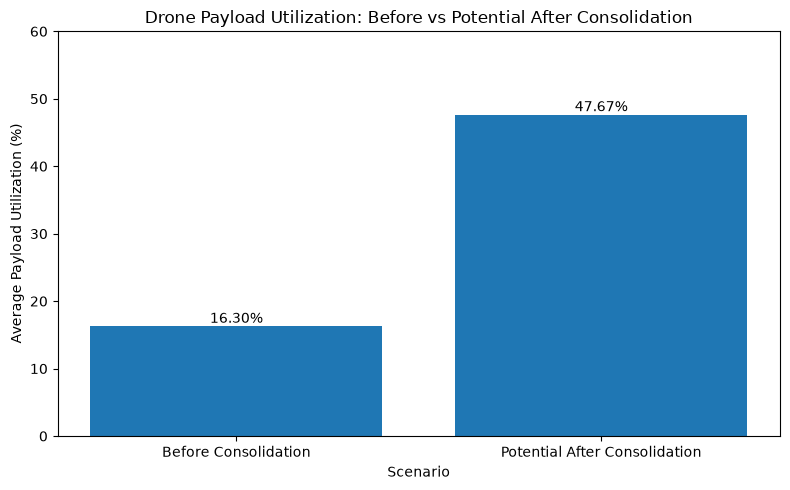

In [26]:
import matplotlib.pyplot as plt

scenarios = [
    'Before Consolidation',
    'Potential After Consolidation'
]

utilization = [
    16.30,
    47.67
]

plt.figure(figsize=(8, 5))

bars = plt.bar(scenarios, utilization)

plt.xlabel("Scenario")
plt.ylabel("Average Payload Utilization (%)")
plt.title("Drone Payload Utilization: Before vs Potential After Consolidation")

for bar, value in zip(bars, utilization):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f}%",
        ha='center',
        va='bottom'
    )

plt.ylim(0, 60)
plt.tight_layout()
plt.show()

# Save the feasible drone payload analysis

In [29]:
feasible_groups.to_csv(
    "../data/drone_payload_optimization.csv",
    index=False
)

print("Drone payload optimization dataset saved successfully.")

Drone payload optimization dataset saved successfully.
